# Hemangiomas — SegFormer (MiT-b0) (preentrenado en ISIC 2018) + augmentation + **5-fold estratificado**

- **Etapa 1 — Preentrenamiento de dominio (una sola vez):** SegFormer se
  entrena sobre **ISIC 2018 Task 1** y se
  guardan esos pesos. Cadena: **ISIC 2018 → hemangiomas**.
- **Etapa 2 — Validación cruzada 5-fold estratificada** (por tipo de lesión):
  en cada pliegue se recargan los pesos de ISIC, se hace *fine-tuning* con
  data augmentation, se elige el umbral en validación y se evalúa en el test.
- **Resultado:** métricas por pliegue y **media**.

> `Entorno de ejecución -> GPU`. Solo vía visible (RGB, 3 canales).

In [ ]:
# PyTorch ya viene en Colab. Solo instalamos transformers.
!pip install -q transformers
print('Listo')

Listo


## Configuración

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ===================== CONFIGURACIÓN =====================
MAT_PATH   = '/C:/Users/josem/Desktop/DATASET_FINAL.pdf'
SAVE_DIR   = '/content/drive/MyDrive/TFG/resultados_segformer_ISIC_kfold'

MODEL_NAME         = 'nvidia/mit-b0'   # backbone SegFormer
EPOCHS            = 25
LR                = 6e-5
IMG_SIZE          = 256
BATCH_SIZE        = 8            # baja a 4 si hay OOM de GPU
SEED              = 42
N_FOLDS           = 5           # <=== validación cruzada estratificada k=5
AUG_FACTOR        = 30
DROP_EMPTY_MASKS  = True

# --- ISIC 2018 (preentrenamiento, una sola vez) ---
ISIC_EPOCHS       = 20
ISIC_MAX_SAMPLES  = 2000        # None = las 2594; baja si falta RAM
ISIC_WEIGHTS      = '/content/isic_pretrain.pt'
# ========================================================

import os
os.makedirs(SAVE_DIR, exist_ok=True)
print('Config lista. Resultados en:', SAVE_DIR)

Mounted at /content/drive
Config lista. Resultados en: /content/drive/MyDrive/TFG/resultados_segformer_ISIC_kfold


## Imports y semillas

In [ ]:
import h5py, numpy as np, cv2, random, glob, gc
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import SegformerForSemanticSegmentation

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_curve, auc

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('PyTorch', torch.__version__, '| dispositivo:', device)

PyTorch 2.11.0+cu128 | dispositivo: cuda


## Normalización, augmentation, dataset y modelo

In [ ]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def augment_pair(img, mask, rng):
    h, w = img.shape[:2]
    angle = rng.uniform(-15, 15); scale = rng.uniform(0.8, 1.2)
    tx = rng.uniform(-0.1, 0.1) * w; ty = rng.uniform(-0.1, 0.1) * h
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, scale)
    M[0, 2] += tx; M[1, 2] += ty
    img_a  = cv2.warpAffine(img,  M, (w, h), flags=cv2.INTER_LINEAR,  borderMode=cv2.BORDER_REFLECT)
    mask_a = cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT)
    if rng.random() < 0.5: img_a = img_a[:, ::-1].copy(); mask_a = mask_a[:, ::-1].copy()
    if rng.random() < 0.5: img_a = img_a[::-1, :].copy(); mask_a = mask_a[::-1, :].copy()
    if rng.random() < 0.3:
        k = int(rng.choice([3, 5])); img_a = cv2.GaussianBlur(img_a, (k, k), 0)
    return np.clip(img_a, 0, 1).astype(np.float32), (mask_a > 0.5).astype(np.float32)

def normalize_to_chw(img_hwc):
    x = (img_hwc - IMAGENET_MEAN) / IMAGENET_STD
    return np.transpose(x, (2, 0, 1)).astype(np.float32)

class SegDataset(Dataset):
    def __init__(self, X, Y, augment, aug_factor=1, seed=SEED):
        self.X = X; self.Y = Y; self.augment = augment
        self.base = len(X)
        self.n = len(X) * aug_factor if augment else len(X)
        self.rng = np.random.default_rng(seed)
    def __len__(self): return self.n
    def __getitem__(self, idx):
        j = idx % self.base
        if self.augment:
            img, mask = augment_pair(self.X[j], self.Y[j, ..., 0], self.rng)
        else:
            img, mask = self.X[j], self.Y[j, ..., 0]
        x = normalize_to_chw(img)
        m = mask[np.newaxis, ...].astype(np.float32)
        return torch.from_numpy(np.ascontiguousarray(x)), torch.from_numpy(np.ascontiguousarray(m))

def bce_dice_loss(logits, masks, smooth=1.0):
    bce = F.binary_cross_entropy_with_logits(logits, masks)
    probs = torch.sigmoid(logits)
    inter = (probs * masks).sum()
    dice = 1.0 - (2.0 * inter + smooth) / (probs.sum() + masks.sum() + smooth)
    return bce + dice

def build_model():
    m = SegformerForSemanticSegmentation.from_pretrained(
        MODEL_NAME, num_labels=1, ignore_mismatched_sizes=True)
    return m.to(device)

def model_logits(model, pixel_values):
    logits = model(pixel_values=pixel_values).logits          # (B,1,H/4,W/4)
    return F.interpolate(logits, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)

@torch.no_grad()
def eval_loss_and_dice(model, X, Y, batch=BATCH_SIZE):
    model.eval(); losses, dices = [], []
    for i in range(0, len(X), batch):
        imgs = np.stack([normalize_to_chw(im) for im in X[i:i+batch]])
        pv = torch.from_numpy(imgs).to(device)
        m  = torch.from_numpy(np.transpose(Y[i:i+batch], (0, 3, 1, 2)).astype(np.float32)).to(device)
        logits = model_logits(model, pv)
        losses.append(bce_dice_loss(logits, m).item())
        pred = (torch.sigmoid(logits) > 0.5).float()
        inter = (pred * m).sum().item()
        dices.append((2*inter + 1) / (pred.sum().item() + m.sum().item() + 1))
    return float(np.mean(losses)), float(np.mean(dices))

@torch.no_grad()
def predict_probs(model, X, batch=BATCH_SIZE):
    model.eval(); out = []
    for i in range(0, len(X), batch):
        imgs = np.stack([normalize_to_chw(im) for im in X[i:i+batch]])
        pv = torch.from_numpy(imgs).to(device)
        logits = model_logits(model, pv)
        out.append(torch.sigmoid(logits).cpu().numpy()[:, 0])
    return np.concatenate(out, axis=0)

def train_model(model, train_loader, X_val, Y_val, epochs, lr, ckpt):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    best_val = float('inf')
    for epoch in range(epochs):
        model.train(); ep = []
        for pv, m in train_loader:
            pv = pv.to(device); m = m.to(device)
            logits = model_logits(model, pv)
            loss = bce_dice_loss(logits, m)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            ep.append(loss.item())
        vl, vd = eval_loss_and_dice(model, X_val, Y_val)
        print(f'  época {epoch+1:02d}/{epochs}  loss={np.mean(ep):.4f}  val_loss={vl:.4f}  val_dice={vd:.4f}')
        if vl < best_val:
            best_val = vl; torch.save(model.state_dict(), ckpt)
    model.load_state_dict(torch.load(ckpt))
    return model

def dice_at(y_true_flat, prob_flat, th):
    yp = (prob_flat > th).astype(int)
    tp = np.sum((yp == 1) & (y_true_flat == 1))
    fp = np.sum((yp == 1) & (y_true_flat == 0))
    fn = np.sum((yp == 0) & (y_true_flat == 1))
    return 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) else 0.0

def compute_metrics(y_true, y_prob, th):
    y_pred = (y_prob > th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    dice = 2*tp/(2*tp+fp+fn) if (2*tp+fp+fn) else 0.0
    f1  = tp/(tp+fp+fn) if (tp+fp+fn) else 0.0
    acc  = (tp+tn)/(tp+tn+fp+fn)
    prec = tp/(tp+fp) if (tp+fp) else 0.0
    sens = tp/(tp+fn) if (tp+fn) else 0.0
    spec = tn/(tn+fp) if (tn+fp) else 0.0
    return dict(dice=dice, f1=f1, exactitud=acc, precision=prec,
                sensibilidad=sens, especificidad=spec)

# ETAPA 1 — Preentrenamiento en ISIC 2018 (una sola vez)
El zip de imágenes pesa ~10.4 GB: la descarga tarda unos minutos la primera vez.

In [ ]:
IMG_URL  = "https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task1-2_Training_Input.zip"
MASK_URL = "https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task1_Training_GroundTruth.zip"

if not os.path.exists("ISIC2018_Task1-2_Training_Input"):
    !wget -q --show-progress "$IMG_URL"  -O images.zip && unzip -q images.zip && rm images.zip
if not os.path.exists("ISIC2018_Task1_Training_GroundTruth"):
    !wget -q --show-progress "$MASK_URL" -O masks.zip  && unzip -q masks.zip  && rm masks.zip

mp_all = sorted(glob.glob("ISIC2018_Task1_Training_GroundTruth/*_segmentation.png"))
isic_pairs = []
for mp in mp_all:
    base = os.path.basename(mp).replace("_segmentation.png", "")
    ip = os.path.join("ISIC2018_Task1-2_Training_Input", base + ".jpg")
    if os.path.exists(ip):
        isic_pairs.append((ip, mp))
random.Random(SEED).shuffle(isic_pairs)
if ISIC_MAX_SAMPLES is not None:
    isic_pairs = isic_pairs[:ISIC_MAX_SAMPLES]
print("Pares ISIC usados:", len(isic_pairs))

# Carga a numpy en [0,1] (la normalización ImageNet la aplica normalize_to_chw)
Xi = np.zeros((len(isic_pairs), IMG_SIZE, IMG_SIZE, 3), np.float32)
Yi = np.zeros((len(isic_pairs), IMG_SIZE, IMG_SIZE, 1), np.float32)
for k, (ip, mp) in enumerate(isic_pairs):
    img = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img.astype(np.float32), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA) / 255.0
    m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
    m = cv2.resize(m, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    Xi[k] = img; Yi[k, ..., 0] = (m > 127).astype(np.float32)

Xi_tr, Xi_val, Yi_tr, Yi_val = train_test_split(Xi, Yi, test_size=0.15, random_state=SEED)
print("ISIC train:", len(Xi_tr), "| ISIC val:", len(Xi_val))

images.zip          100%[===================>]  10.40G  15.8MB/s    in 11m 30s 
masks.zip           100%[===================>]  26.13M  8.38MB/s    in 3.1s    
Pares ISIC usados: 2000
ISIC train: 1700 | ISIC val: 300


In [ ]:
# Preentrenamiento del modelo en ISIC
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

isic_model = build_model()
isic_train_ds = SegDataset(Xi_tr, Yi_tr, augment=False)
isic_loader = DataLoader(isic_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

isic_model = train_model(isic_model, isic_loader, Xi_val, Yi_val,
                         ISIC_EPOCHS, LR, '/content/_isic_best.pt')
torch.save(isic_model.state_dict(), ISIC_WEIGHTS)
print('Pesos de ISIC guardados en:', ISIC_WEIGHTS)

del isic_model, Xi, Yi, Xi_tr, Xi_val, Yi_tr, Yi_val, isic_loader, isic_train_ds
gc.collect(); torch.cuda.empty_cache()

config.json:   0%|          | 0.00/70.0k [00:00<?, ?B/s]

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 14.4MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.batch_norm.running_mean                     | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.bias                             

model.safetensors: reconstructing file:   0%|          |  0.00B / 14.3MB            

model.safetensors: downloading bytes:           |  0.00B            

  época 01/20  loss=0.6910  val_loss=0.5107  val_dice=0.8517
  época 02/20  loss=0.4192  val_loss=0.3838  val_dice=0.8603
  época 03/20  loss=0.3113  val_loss=0.3302  val_dice=0.8805
  época 04/20  loss=0.2514  val_loss=0.2839  val_dice=0.8888
  época 05/20  loss=0.2185  val_loss=0.2779  val_dice=0.8893
  época 06/20  loss=0.1975  val_loss=0.2629  val_dice=0.8918
  época 07/20  loss=0.1777  val_loss=0.2585  val_dice=0.8940
  época 08/20  loss=0.1712  val_loss=0.2630  val_dice=0.8934
  época 09/20  loss=0.1557  val_loss=0.2609  val_dice=0.8937
  época 10/20  loss=0.1553  val_loss=0.2518  val_dice=0.8967
  época 11/20  loss=0.1497  val_loss=0.2779  val_dice=0.8825
  época 12/20  loss=0.1400  val_loss=0.2602  val_dice=0.8943
  época 13/20  loss=0.1296  val_loss=0.2786  val_dice=0.8909
  época 14/20  loss=0.1231  val_loss=0.2605  val_dice=0.8985
  época 15/20  loss=0.1128  val_loss=0.2549  val_dice=0.8991
  época 16/20  loss=0.1114  val_loss=0.2804  val_dice=0.8939
  época 17/20  loss=0.11

# ETAPA 2 — Hemangiomas con validación cruzada 5-fold

## Carga del dataset desde el `.mat`

In [ ]:
def _decode(sub):
    return ''.join(chr(c) for c in sub[()].flatten())

def load_mat_dataset(path, img_size, drop_empty=True):
    f = h5py.File(path, 'r')
    ds = f['DATASET_UNIDO']
    N = ds.shape[0]
    X, Y, types, names = [], [], [], []
    n_empty = 0
    for n in range(N):
        cell = f[ds[n, 0]]
        name = _decode(f[cell[0, 0]])
        mask = f[cell[1, 0]][()].astype(np.uint8)
        typ  = _decode(f[cell[2, 0]])
        img  = np.transpose(f[cell[3, 0]][()], (1, 2, 0))
        if drop_empty and mask.sum() == 0:
            n_empty += 1
            continue
        img_r  = cv2.resize(img.astype(np.float32), (img_size, img_size), interpolation=cv2.INTER_AREA)
        mask_r = cv2.resize(mask, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
        X.append(img_r); Y.append(mask_r); types.append(typ); names.append(name)
    f.close()
    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32)[..., np.newaxis]
    print('Muestras cargadas:', len(X), '| descartadas (máscara vacía):', n_empty)
    return X, Y, np.array(types), np.array(names)

X, Y, types, names = load_mat_dataset(MAT_PATH, IMG_SIZE, DROP_EMPTY_MASKS)
print('X:', X.shape, '| Y:', Y.shape)
print('Tipos:', dict(zip(*np.unique(types, return_counts=True))))

Muestras cargadas: 127 | descartadas (máscara vacía): 3
X: (127, 256, 256, 3) | Y: (127, 256, 256, 1)
Tipos: {np.str_('NUEVO_TIPO'): np.int64(30), np.str_('linfatica'): np.int64(12), np.str_('mixto'): np.int64(27), np.str_('prof'): np.int64(8), np.str_('superf'): np.int64(50)}


## Bucle de validación cruzada 5-fold estratificada
En cada pliegue el modelo se reinicializa con los pesos de ISIC y se afina.

In [ ]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_results = []
oof_true, oof_prob = [], []
last = {}

for fold, (tr_idx, te_idx) in enumerate(skf.split(X, types), start=1):
    print(f"\n===== FOLD {fold}/{N_FOLDS} =====")
    X_trf, X_test = X[tr_idx], X[te_idx]
    Y_trf, Y_test = Y[tr_idx], Y[te_idx]
    t_trf         = types[tr_idx]

    X_train, X_val, Y_train, Y_val = train_test_split(
        X_trf, Y_trf, test_size=0.20, random_state=SEED, stratify=t_trf)

    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    model = build_model()
    model.load_state_dict(torch.load(ISIC_WEIGHTS))       # transfer desde ISIC

    train_ds = SegDataset(X_train, Y_train, augment=True, aug_factor=AUG_FACTOR, seed=SEED + fold)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    ckpt = os.path.join(SAVE_DIR, f'modelo_fold{fold}.pt')
    model = train_model(model, train_loader, X_val, Y_val, EPOCHS, LR, ckpt)

    val_prob = predict_probs(model, X_val).flatten()
    val_true = Y_val.astype(int).flatten()
    ths = np.round(np.linspace(0.05, 0.90, 18), 3)
    best_th = float(ths[int(np.argmax([dice_at(val_true, val_prob, t) for t in ths]))])

    test_prob = predict_probs(model, X_test)              # (N, H, W)
    met = compute_metrics(Y_test[..., 0].astype(int).flatten(), test_prob.flatten(), best_th)
    met['fold'] = fold; met['umbral'] = best_th
    fold_results.append(met)
    print(f"  Fold {fold}: umbral={best_th} | Dice={met['dice']:.4f} | F1={met['f1']:.4f}")

    oof_true.append(Y_test[..., 0].astype(int).flatten())
    oof_prob.append(test_prob.flatten())
    last = dict(X_test=X_test, Y_test=Y_test, prob=test_prob, th=best_th)

    del model, train_loader, train_ds
    gc.collect(); torch.cuda.empty_cache()


===== FOLD 1/5 =====


[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.batch_norm.running_mean                     | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.bias                             

  época 01/25  loss=0.2973  val_loss=0.3244  val_dice=0.8293
  época 02/25  loss=0.1960  val_loss=0.2625  val_dice=0.8617
  época 03/25  loss=0.1513  val_loss=0.3051  val_dice=0.8490
  época 04/25  loss=0.1437  val_loss=0.3337  val_dice=0.8402
  época 05/25  loss=0.1203  val_loss=0.2891  val_dice=0.8590
  época 06/25  loss=0.1110  val_loss=0.3027  val_dice=0.8558
  época 07/25  loss=0.1006  val_loss=0.3093  val_dice=0.8556
  época 08/25  loss=0.1003  val_loss=0.3888  val_dice=0.8853
  época 09/25  loss=0.0921  val_loss=0.3428  val_dice=0.8846
  época 10/25  loss=0.0880  val_loss=0.3491  val_dice=0.8385
  época 11/25  loss=0.0861  val_loss=0.3329  val_dice=0.8498
  época 12/25  loss=0.0813  val_loss=0.3393  val_dice=0.8465
  época 13/25  loss=0.0797  val_loss=0.3068  val_dice=0.8583
  época 14/25  loss=0.0781  val_loss=0.3189  val_dice=0.8572
  época 15/25  loss=0.0791  val_loss=0.3286  val_dice=0.8521
  época 16/25  loss=0.0746  val_loss=0.3351  val_dice=0.8511
  época 17/25  loss=0.07

...

  época 01/25  loss=0.2914  val_loss=0.3284  val_dice=0.8874
  época 02/25  loss=0.1867  val_loss=0.3570  val_dice=0.8943
  época 03/25  loss=0.1558  val_loss=0.3456  val_dice=0.8851
  época 04/25  loss=0.1274  val_loss=0.3488  val_dice=0.8914
  época 05/25  loss=0.1178  val_loss=0.3503  val_dice=0.8883
  época 06/25  loss=0.1069  val_loss=0.3537  val_dice=0.8952
  época 07/25  loss=0.0972  val_loss=0.4002  val_dice=0.8735
  época 08/25  loss=0.0935  val_loss=0.3828  val_dice=0.8858
  época 09/25  loss=0.0936  val_loss=0.3870  val_dice=0.8864
  época 10/25  loss=0.0887  val_loss=0.3785  val_dice=0.8954
  época 11/25  loss=0.0836  val_loss=0.3688  val_dice=0.8961
  época 12/25  loss=0.0793  val_loss=0.3766  val_dice=0.8846
  época 13/25  loss=0.0772  val_loss=0.3761  val_dice=0.8917
  época 14/25  loss=0.0742  val_loss=0.4006  val_dice=0.8848
  época 15/25  loss=0.0762  val_loss=0.3928  val_dice=0.8878
  época 16/25  loss=0.0740  val_loss=0.4022  val_dice=0.8992
  época 17/25  loss=0.07

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.batch_norm.running_mean                     | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.bias                             

  época 01/25  loss=0.3053  val_loss=0.3283  val_dice=0.8965
  época 02/25  loss=0.1867  val_loss=0.3099  val_dice=0.8844
  época 03/25  loss=0.1502  val_loss=0.3276  val_dice=0.8814
  época 04/25  loss=0.1311  val_loss=0.3146  val_dice=0.8985
  época 05/25  loss=0.1165  val_loss=0.3280  val_dice=0.8985
  época 06/25  loss=0.1074  val_loss=0.3613  val_dice=0.8885
  época 07/25  loss=0.0989  val_loss=0.3435  val_dice=0.8505
  época 08/25  loss=0.0942  val_loss=0.3520  val_dice=0.8853
  época 09/25  loss=0.0942  val_loss=0.3519  val_dice=0.8902
  época 10/25  loss=0.0855  val_loss=0.3926  val_dice=0.8856
  época 11/25  loss=0.0834  val_loss=0.3503  val_dice=0.8853
  época 12/25  loss=0.0850  val_loss=0.4076  val_dice=0.8861
  época 13/25  loss=0.0775  val_loss=0.3737  val_dice=0.8823
  época 14/25  loss=0.0735  val_loss=0.4109  val_dice=0.8828
  época 15/25  loss=0.0719  val_loss=0.3579  val_dice=0.8966
  época 16/25  loss=0.0721  val_loss=0.4119  val_dice=0.8965
  época 17/25  loss=0.06

## Resultados: por pliegue y media

In [ ]:
cols = ['fold', 'umbral', 'dice', 'f1', 'exactitud', 'precision', 'sensibilidad', 'especificidad']
df = pd.DataFrame(fold_results)[cols]
print(df.round(4).to_string(index=False))

metric_cols = ['dice', 'f1', 'exactitud', 'precision', 'sensibilidad', 'especificidad']
mean, std = df[metric_cols].mean(), df[metric_cols].std()
print("\n===== Media =====")
for cc in metric_cols:
    print(f"  {cc:14s}: {mean[cc]:.4f} ± {std[cc]:.4f}")

df.to_csv(os.path.join(SAVE_DIR, 'metricas_kfold.csv'), index=False)
with open(os.path.join(SAVE_DIR, 'resumen_kfold.txt'), 'w') as fp_:
    for cc in metric_cols:
        fp_.write(f"{cc}: {mean[cc]:.4f}\n")
print("\nGuardado: metricas_kfold.csv y resumen_kfold.txt")

===== Media =====
  dice          : 0.8732
  f1            : 0.8548
  exactitud     : 0.9724
  precision     : 0.9272
  sensibilidad  : 0.9187
  especificidad : 0.9905

Guardado: metricas_kfold.csv y resumen_kfold.txt


## Curva ROC global (out-of-fold)

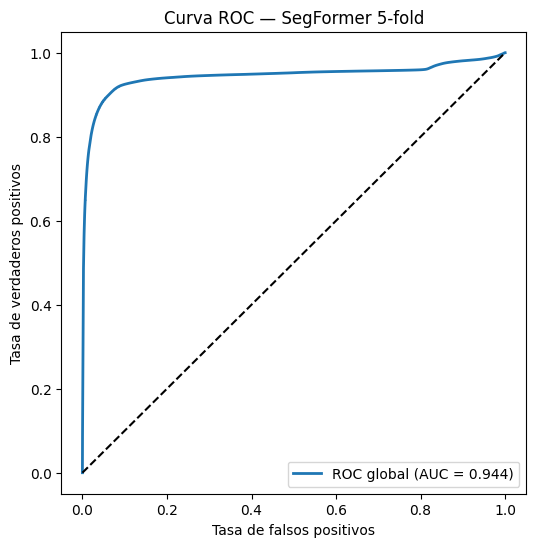

In [ ]:
y_all = np.concatenate(oof_true)
p_all = np.concatenate(oof_prob)
fpr, tpr, _ = roc_curve(y_all, p_all); roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, lw=2, label='ROC global (AUC = {:.3f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de falsos positivos'); plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC — SegFormer '); plt.legend(loc='lower right')
plt.savefig(os.path.join(SAVE_DIR, 'roc_kfold.png'), dpi=120); plt.show()